In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

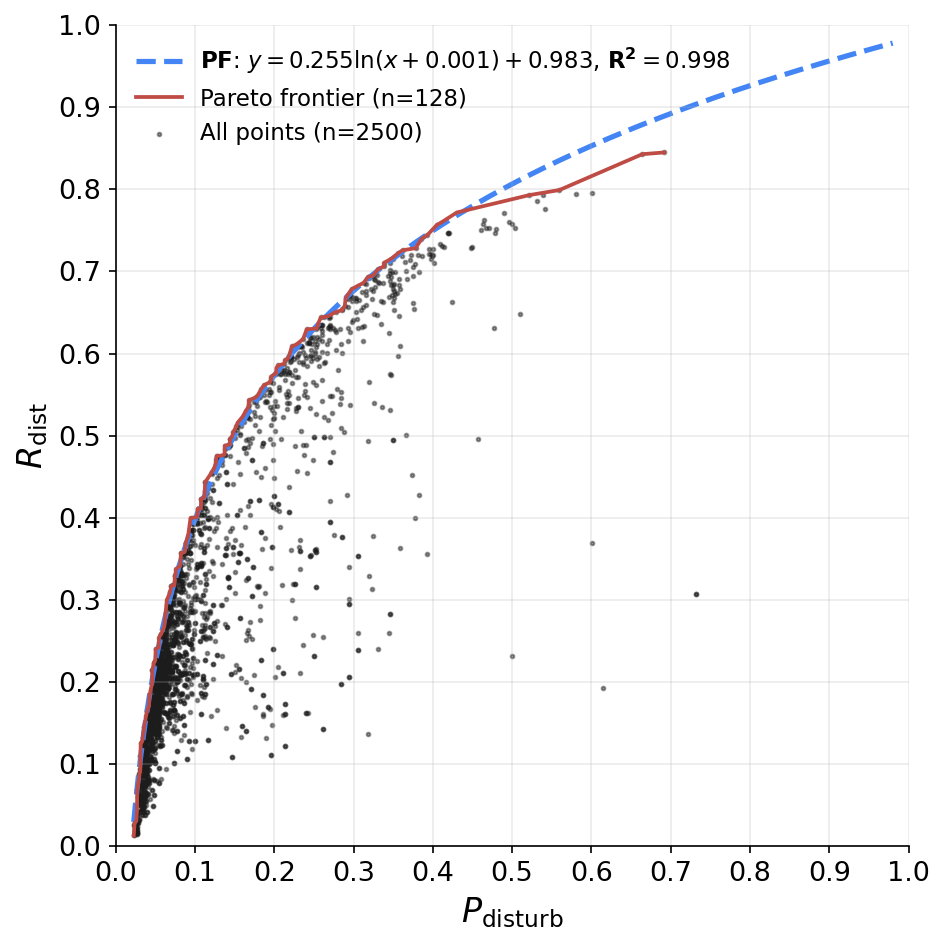

In [32]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

xcol = "p_disturbance"
ycol = "r_dist"

base_file = Path("pareto.csv")
sparse_file = Path("pareto_sparse.csv")

# -------------------------
# load / accumulate results
# -------------------------
df_new = pd.read_csv(base_file)
df_new[ycol] = df_new[ycol] + 1

if sparse_file.exists():
    df_existing = pd.read_csv(sparse_file)
    df_all = pd.concat([df_existing, df_new], ignore_index=True)
else:
    df_all = df_new.copy()

# remove duplicates only on plotted coordinates
df_all = df_all.drop_duplicates(subset=[xcol, ycol]).copy()

# save updated accumulated dataset
df_all.to_csv(sparse_file, index=False)

# keep valid rows only
df_all = df_all[[xcol, ycol]].dropna().copy()

df_all = df_all.sample(2500, replace=False, random_state=0)
# -------------------------
# Pareto frontier
# minimize x, maximize y
# -------------------------
pts = df_all[[xcol, ycol]].to_numpy()

# sort by x ascending, y descending
pts = pts[np.lexsort((-pts[:, 1], pts[:, 0]))]

pareto = []
best_y = -np.inf

for px, py in pts:
    if py > best_y:
        pareto.append((px, py))
        best_y = py

pareto = np.array(pareto)

# -------------------------
# logarithmic fit to Pareto
# y = a * ln(x + c) + b
# choose c so x + c > 0
# -------------------------
x_p = pareto[:, 0]
y_p = pareto[:, 1]

eps = 1e-3
c = max(eps, -x_p.min() + eps)   # ensures positivity inside log
X = np.log(x_p + c)

a, b = np.polyfit(X, y_p, 1)

# predictions on Pareto points for R^2
y_pred_p = a * np.log(x_p + c) + b
ss_res = np.sum((y_p - y_pred_p) ** 2)
ss_tot = np.sum((y_p - np.mean(y_p)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

x_fit = np.linspace(x_p.min(), 0.98, 400)
y_fit = a * np.log(x_fit + c) + b

# -------------------------
# plot
# -------------------------
fig, ax = plt.subplots(figsize=(6.4, 6.4), dpi=150)

# log fit
fit_label = (
    rf"$\mathbf{{PF}}$: $y = {a:.3f}\ln(x + {c:.3g}) {b:+.3f}$, $\mathbf{{R^2}} = {r2:.3f}$"
)

ax.plot(
    x_fit,
    y_fit,
    color="#4385f5",
    linestyle="--",
    linewidth=2.5,
    label=fit_label,
    zorder=1,
)

ax.plot(
    pareto[:, 0],
    pareto[:, 1],
    color="#be4c44",
    linestyle="-",
    linewidth=1.8,
    markersize=3.5,
    label=f"Pareto frontier (n={len(pareto)})",
    zorder=2,
)

# all points
ax.scatter(
    df_all[xcol],
    df_all[ycol],
    s=12,
    alpha=0.45,
    color="#1C1C1C",
    marker=".",
    label=f"All points (n={len(df_all)})",
    zorder=0,
)

# labels
ax.set_xlabel(r"$P_{\text{disturb}}$", fontsize=16, fontweight="bold")
ax.set_ylabel(r"$R_{\text{dist}}$", fontsize=16, fontweight="bold")

# ticks: [0,1] with 11 ticks
ticks = np.linspace(0, 1, 11)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.tick_params(axis="both", labelsize=13)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# grid
ax.grid(True, alpha=0.25)

ax.legend(fontsize=11, frameon=False, loc="upper left", )
plt.tight_layout()
plt.savefig("figures/pareto.png", dpi=300, transparent=True)
plt.show()